In [1]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
import poppy
import skimage
from skimage.registration import phase_cross_correlation
import copy
from importlib import reload
from IPython.display import clear_output, display
import multiprocessing
import subprocess
import glob
from pathlib import Path
import os
cwd = Path(os.getcwd())

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle

import magpyx
from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient

client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

import lina
from lina.math_module import xp, xcipy, ensure_np_array
from lina import utils, rt_utils

import fsm_utils
import cam_utils

bias = np.array([[5.0, 5.0, 5.0]]).T
zero = np.array([[0,0,0]]).T

wavelength = 633e-9
fl = 500e-3
fsm_pupil_diam = 6.8e-3
as_per_lamD = (wavelength/fsm_pupil_diam*u.radian).to(u.arcsec)
print(as_per_lamD)

pxscl_lamD = 3.45e-6 / (fl * wavelength/fsm_pupil_diam)
print(pxscl_lamD)

/opt/conda/envs/km310/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')
INFO:purepyindi2.transports:Opening localhost:7624...
INFO:purepyindi2.transports:Connected to localhost:7624


19.200826816825295 arcsec
0.07412322274881515


In [2]:
reload(cam_utils)
cam = cam_utils.CAM('camfsm')


In [40]:
npsf = 256
# cam.set_roi(795, 710, npsf, client0)
cam.set_roi(860, 670, npsf, client0)

cam.set_exptime(0.0003, client0)

In [ ]:
cam.set_exptime(0.001, client0)

INFO:utils:Got semaphore index 1.


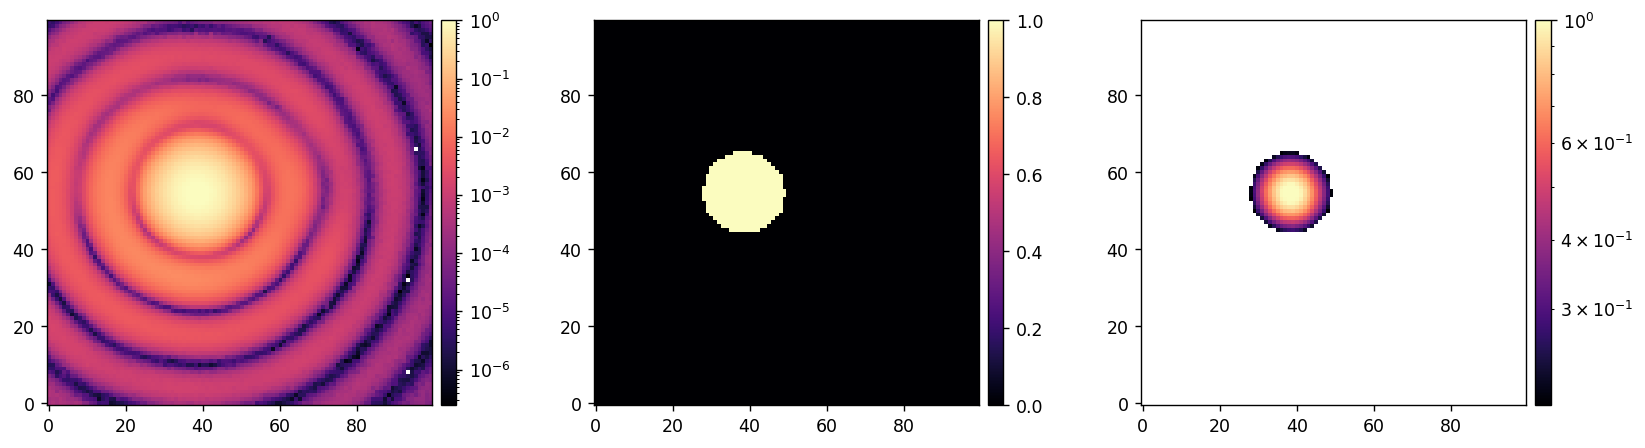

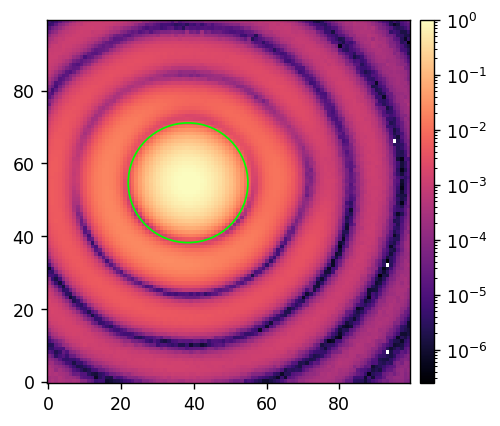

In [5]:
cam.Nframes = 1000
im = cam.snap()

reload(utils)
cen = utils.centroid(im, thresh=0.2, plot=True)
utils.imshow(
    [im], 
    norms=[LogNorm()],
    all_patches=[[Circle(cen, 1.22/pxscl_lamD, fill=False, color='lime')]],
)


# initialize the FSM channel.

In [51]:
fsm_stream0 = ImageStream('dm01disp00')
fsm_stream1 = ImageStream('dm01disp02')
fsm_stream1.shape

(1, 3)

In [52]:
fsm_stream1.write(np.array([[0, 100, 0]]).T)

In [ ]:
fsm_stream0.write(bias)

In [11]:
fsm_stream0.write(zero)

In [53]:
fsm_stream1.write(zero)

In [11]:
def command_fsm(client, p=None, tip=None, tilt=None):
    # client.wait_for_properties(
    #         ['pi727.pos_1.target',
    #          'pi727.pos_2.target',
    #          'pi727.pos_3.target',]
    #     )
    if p is not None: client['pi727.pos_1.target'] = p
    if tip is not None: client['pi727.pos_2.target'] = tip
    if tilt is not None: client['pi727.pos_3.target'] = tilt
    return



In [54]:
command_fsm(client, p=0)

# Make FSM do a circle

In [41]:
reload(fsm_utils)
amp = 1*as_per_lamD
print(amp)

freq = 1*u.Hz
t_max = (1/freq).to(u.s)
Nsamps = 19
Nsamps = 37
# Nsamps = 181
times = np.linspace(0, t_max, Nsamps)
delt = (times[1]-times[0]).to_value(u.s)

tip_wave = amp*np.sin(2*np.pi*freq.to_value(u.Hz)*times.to_value(u.s))/np.sqrt(2)
tilt_wave = amp*np.cos(2*np.pi*freq.to_value(u.Hz)*times.to_value(u.s))/np.sqrt(2)
disp_commands = np.zeros((Nsamps, 3, 1))
for i in range(Nsamps):
    disp_commands[i] = fsm_utils.get_fsm_disps(tip=tip_wave[i], tilt=tilt_wave[i])

19.200826816825295 arcsec


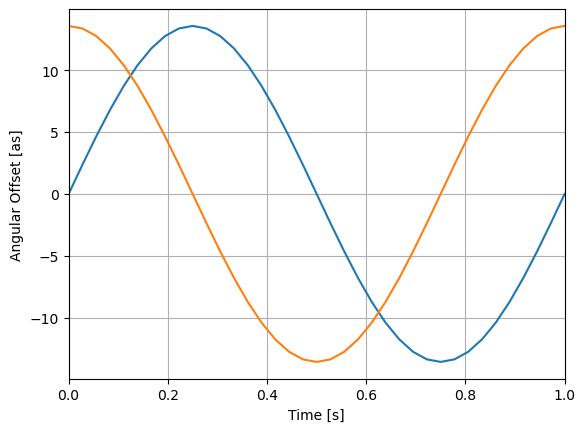

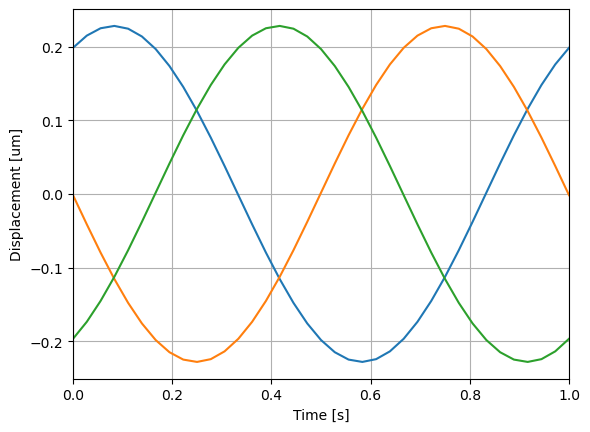

In [8]:
import matplotlib.pyplot as plt
plt.plot(times, tip_wave)
plt.plot(times, tilt_wave)
plt.xlim([0, t_max.to_value(u.s)])
plt.xlabel('Time [s]')
plt.ylabel('Angular Offset [as]')
plt.grid()
plt.show()

plt.plot(times, disp_commands[:,0])
plt.plot(times, disp_commands[:,1])
plt.plot(times, disp_commands[:,2])
plt.xlabel('Time [s]')
plt.ylabel('Displacement [um]')
plt.xlim([0, t_max.to_value(u.s)])
plt.grid()
plt.show()

In [24]:
freq = 0.25 * Nsamps
try:
    print('Modulating FSM ...')
    i = 0
    while i<Nsamps+1:
        if i==Nsamps-1:
            i = 0
        fsm_stream1.write(volt_commands[i])
        time.sleep(1/freq)
        i += 1
        # print(i)
except KeyboardInterrupt:
    print('FSM modulation stopped!')
    fsm_stream1.write(zero)

Modulating FSM ...
FSM modulation stopped!


In [25]:
fsm_stream0.write(zero)
fsm_stream1.write(zero)

# Make FSM do a circle

In [46]:
reload(fsm_utils)
amp = 0.5*as_per_lamD.to_value(u.microradian)
print(amp)

freq = 1*u.Hz
t_max = (1/freq).to(u.s)
Nsamps = 19
Nsamps = 37
# Nsamps = 181
times = np.linspace(0, t_max, Nsamps)
delt = (times[1]-times[0]).to_value(u.s)

tip_wave = amp*np.sin(2*np.pi*freq.to_value(u.Hz)*times.to_value(u.s))
tilt_wave = amp*np.cos(2*np.pi*freq.to_value(u.Hz)*times.to_value(u.s))
disp_commands = np.array([tip_wave, tilt_wave])

46.544117647058826


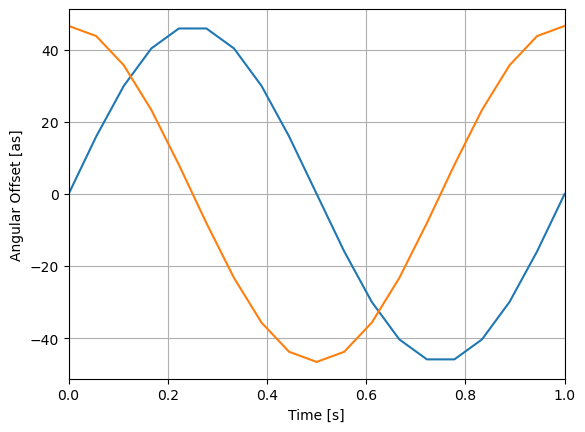

In [44]:
import matplotlib.pyplot as plt
plt.plot(times, tip_wave)
plt.plot(times, tilt_wave)
plt.xlim([0, t_max.to_value(u.s)])
plt.xlabel('Time [s]')
plt.ylabel('Angular Offset [as]')
plt.grid()
plt.show()

In [26]:
disp_commands.shape, disp_commands[0,10]

((2, 37), 64.82331825331941)

In [47]:
freq = 0.25 * Nsamps
try:
    print('Modulating FSM ...')
    i = 0
    while i<Nsamps+1:
        if i==Nsamps-1:
            i = 0
        command_fsm(client, tip=disp_commands[0,i], tilt=disp_commands[1,i])
        time.sleep(1/freq)
        i += 1
        # print(i)
except KeyboardInterrupt:
    print('FSM modulation stopped!')
    command_fsm(client, tip=0.0, tilt=0.0)

Modulating FSM ...
FSM modulation stopped!


In [30]:
command_fsm(client, tip=0.0, tilt=0.0)